In [120]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, f_classif

In [121]:
# Cell 2: Load your dataset
df = pd.read_csv('academIQ_burnout_dataset_final.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nBurnout risk distribution:")
print(df['burnout_risk'].value_counts())
df.head()

Shape: (16089, 24)

Columns: ['student_id', 'all_clicks', 'active_days', 'access_frequency', 'material_clicks', 'avg_quiz_score', 'quiz_attempts', 'avg_assignment_score', 'assignment_submissions', 'final_grade', 'total_time_spent', 'procrastination_index', 'late_submission_count', 'max_burnout_score', 'avg_burnout_score', 'spike_count', 'crash_count', 'decline_weeks', 'avg_instability', 'max_instability', 'burnout_weeks', 'total_weeks', 'burnout_week_ratio', 'burnout_risk']

Burnout risk distribution:
burnout_risk
0    15496
1      593
Name: count, dtype: int64


,student_id,all_clicks,active_days,access_frequency,material_clicks,avg_quiz_score,quiz_attempts,avg_assignment_score,assignment_submissions,final_grade,...,avg_burnout_score,spike_count,crash_count,decline_weeks,avg_instability,max_instability,burnout_weeks,total_weeks,burnout_week_ratio,burnout_risk
0,6516,2791,159,17.553459,174.0,0.0,0.0,61.8,5.0,65,...,0.265912,8.0,4.0,15.0,0.057743,0.161905,15.0,35.0,0.428571,1
1,8462,646,56,11.535714,93.0,0.0,0.0,87.0,7.0,30,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,NaN,0.000000,0
2,11391,934,40,23.350000,18.0,0.0,0.0,82.0,5.0,65,...,0.253208,5.0,3.0,12.0,0.034244,0.141126,5.0,26.0,0.192308,0
3,23629,161,16,10.062500,2.0,100.0,2.0,65.0,2.0,40,...,0.078753,0.0,0.0,1.0,0.009632,0.015584,0.0,4.0,0.000000,0
4,23698,910,70,13.000000,48.0,75.0,4.0,72.5,4.0,65,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,NaN,0.000000,0


In [122]:
# Cell 3: Define features — leaking columns already removed
feature_cols = [
    'all_clicks',
    'active_days',
    'access_frequency',
    'material_clicks',
    'avg_quiz_score',
    'quiz_attempts',
    'avg_assignment_score',
    'assignment_submissions',
    'total_time_spent',
    'procrastination_index',
    'late_submission_count',
    'spike_count',
    'crash_count',
    'decline_weeks',
    'avg_instability',
    'max_instability'
]

X = df[feature_cols].copy()
y = df['burnout_risk'].copy()

X = X.fillna(X.median())

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (16089, 16)
Target distribution:
burnout_risk
0    15496
1      593
Name: count, dtype: int64


In [124]:
# Cell 4: Split on real data only — no synthetic data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} students")
print(f"Testing set size:  {X_test.shape[0]} students")
print(f"\nLabel distribution in training set:")
print(y_train.value_counts())
print(f"\nLabel distribution in test set:")
print(y_test.value_counts())

Training set size: 12871 students
Testing set size:  3218 students

Label distribution in training set:
burnout_risk
0    12397
1      474
Name: count, dtype: int64

Label distribution in test set:
burnout_risk
0    3099
1     119
Name: count, dtype: int64


In [125]:
# Cell 5: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled ✓")
print("No synthetic data used — 100% real students ✓")

Features scaled ✓
No synthetic data used — 100% real students ✓


In [126]:
# Cell 6: Feature selection — keep only statistically significant features
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    'feature': feature_cols,
    'score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('score', ascending=False)

print("Feature scores (higher = more important):")
print(feature_scores.to_string(index=False))

# Keep only statistically significant features (p_value < 0.05)
significant_features = feature_scores[
    feature_scores['p_value'] < 0.05
]['feature'].tolist()

print(f"\nOriginal features: {len(feature_cols)}")
print(f"Selected features: {len(significant_features)}")
print(f"\nDropped: {[f for f in feature_cols if f not in significant_features]}")

X_train_selected = X_train_scaled[:, [feature_cols.index(f) for f in significant_features]]
X_test_selected  = X_test_scaled[:,  [feature_cols.index(f) for f in significant_features]]

print("\nNew training set shape:", X_train_selected.shape)
print("New test set shape:    ", X_test_selected.shape)

Feature scores (higher = more important):
               feature       score       p_value
       max_instability 9746.109864  0.000000e+00
       avg_instability 8788.943058  0.000000e+00
           crash_count 6679.777541  0.000000e+00
           spike_count 6381.160740  0.000000e+00
         decline_weeks 5576.438215  0.000000e+00
            all_clicks  563.758705 5.270880e-122
      total_time_spent  563.758705 5.270880e-122
           active_days  514.718535 9.150801e-112
      access_frequency  175.778745  7.386211e-40
  avg_assignment_score   66.058010  4.776551e-16
         quiz_attempts   36.676947  1.433042e-09
       material_clicks   32.687226  1.106512e-08
        avg_quiz_score   29.910208  4.609728e-08
assignment_submissions   20.904781  4.871877e-06
 procrastination_index   16.157019  5.863430e-05
 late_submission_count    1.202887  2.727659e-01

Original features: 16
Selected features: 15

Dropped: ['late_submission_count']

New training set shape: (12871, 15)
New tes

In [127]:
# Cell 7: Train Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_selected, y_train)
print("Random Forest model trained ✓")

Random Forest model trained ✓


In [128]:
# Cell 8: Make predictions with threshold comparison then set best threshold
y_prob = model.predict_proba(X_test_selected)[:, 1]

# Compare thresholds
for threshold in [0.50, 0.55, 0.60, 0.65, 0.70]:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred_thresh,
                                target_names=['Safe', 'Burnout Risk']))

# Best threshold chosen based on results
BEST_THRESHOLD = 0.50
y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

print(f"\nUsing threshold: {BEST_THRESHOLD}")
print(f"Predicted at-risk students: {y_pred.sum()}")
print(f"Actual at-risk students:    {y_test.sum()}")


--- Threshold: 0.5 ---
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      3099
Burnout Risk       0.88      0.89      0.89       119

    accuracy                           0.99      3218
   macro avg       0.94      0.94      0.94      3218
weighted avg       0.99      0.99      0.99      3218


--- Threshold: 0.55 ---
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      3099
Burnout Risk       0.89      0.87      0.88       119

    accuracy                           0.99      3218
   macro avg       0.94      0.93      0.94      3218
weighted avg       0.99      0.99      0.99      3218


--- Threshold: 0.6 ---
              precision    recall  f1-score   support

        Safe       0.99      1.00      1.00      3099
Burnout Risk       0.89      0.85      0.87       119

    accuracy                           0.99      3218
   macro avg       0.94      0.92      0.93      3218
w

In [129]:
# Cell 9: Classification report with best threshold
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(
    y_test, y_pred,
    target_names=['Safe', 'Burnout Risk']
))

auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc:.4f}")

if auc >= 0.90:
    print("Excellent model ✓")
elif auc >= 0.80:
    print("Good model ✓")
elif auc >= 0.70:
    print("Acceptable model")
else:
    print("Model needs improvement")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      3099
Burnout Risk       0.88      0.89      0.89       119

    accuracy                           0.99      3218
   macro avg       0.94      0.94      0.94      3218
weighted avg       0.99      0.99      0.99      3218

AUC Score: 0.9980
Excellent model ✓


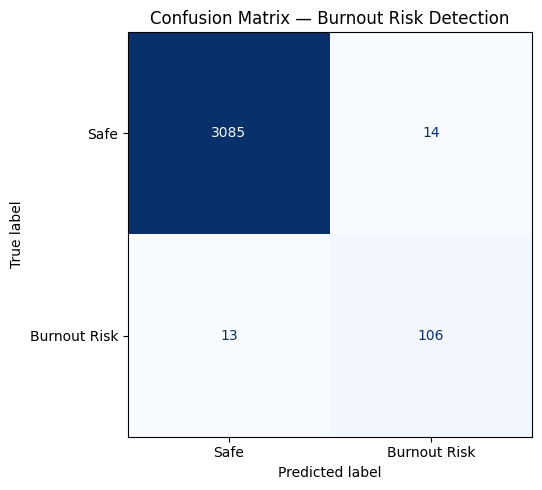


Correctly identified at-risk students (TP): 106
Missed at-risk students (FN):               13
Falsely flagged safe students (FP):         14
Correctly identified safe students (TN):    3085


In [130]:
# Cell 10: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Safe', 'Burnout Risk']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Burnout Risk Detection')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nCorrectly identified at-risk students (TP): {tp}")
print(f"Missed at-risk students (FN):               {fn}")
print(f"Falsely flagged safe students (FP):         {fp}")
print(f"Correctly identified safe students (TN):    {tn}")

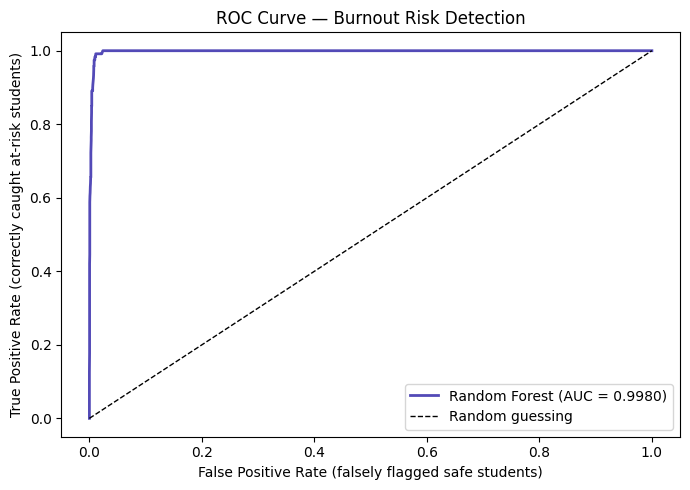

In [131]:
# Cell 11: ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#534AB7', lw=2,
         label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random guessing')
plt.xlabel('False Positive Rate (falsely flagged safe students)')
plt.ylabel('True Positive Rate (correctly caught at-risk students)')
plt.title('ROC Curve — Burnout Risk Detection')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

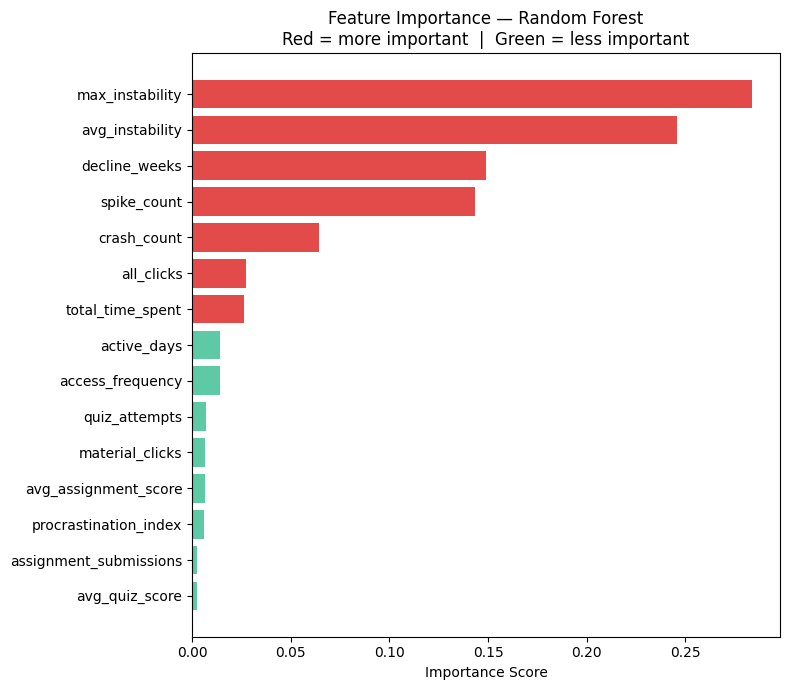


Top 5 most important features:
        feature  importance
max_instability    0.283692
avg_instability    0.245478
  decline_weeks    0.148922
    spike_count    0.143190
    crash_count    0.064472


In [132]:
# Cell 12: Feature importance from Random Forest
importance_df = pd.DataFrame({
    'feature': significant_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#E24B4A' if x > importance_df['importance'].median()
          else '#5DCAA5' for x in importance_df['importance']]

plt.figure(figsize=(8, 7))
plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest\nRed = more important  |  Green = less important')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(importance_df.sort_values('importance', ascending=False)
      .head(5)[['feature', 'importance']].to_string(index=False))

In [133]:
# Cell 13: Apply model to all real students
X_real = df[feature_cols].fillna(df[feature_cols].median())
X_real_scaled = scaler.transform(X_real)
X_real_selected = X_real_scaled[:, [feature_cols.index(f) for f in significant_features]]

df['burnout_probability'] = model.predict_proba(X_real_selected)[:, 1]
df['burnout_predicted']   = (df['burnout_probability'] >= BEST_THRESHOLD).astype(int)

def get_risk_level(prob):
    if prob >= 0.80:
        return 'High Risk'
    elif prob >= 0.55:
        return 'Medium Risk'
    elif prob >= 0.30:
        return 'Low Risk'
    else:
        return 'Safe'

df['risk_level'] = df['burnout_probability'].apply(get_risk_level)

print("Risk level distribution:")
print(df['risk_level'].value_counts())

print("\nSample predictions:")
df[['student_id', 'burnout_probability',
    'burnout_predicted', 'risk_level']].head(10)

Risk level distribution:
risk_level
Safe           15463
High Risk        488
Medium Risk      103
Low Risk          35
Name: count, dtype: int64

Sample predictions:


,student_id,burnout_probability,burnout_predicted,risk_level
0,6516,0.98,1,High Risk
1,8462,0.00,0,Safe
2,11391,0.50,1,Low Risk
3,23629,0.00,0,Safe
4,23698,0.00,0,Safe
5,23798,0.00,0,Safe
6,24213,0.00,0,Safe
7,24213,0.00,0,Safe
8,24734,0.00,0,Safe
9,25107,0.00,0,Safe


In [135]:
# Cell 14: Save final results
df.to_csv('burnout_model_results.csv', index=False)

from google.colab import files
files.download('burnout_model_results.csv')

print("Saved ✓")
print(f"\nFinal dataset shape: {df.shape}")
print(f"\nRisk level summary:")
print(df['risk_level'].value_counts())
print(f"\nModel AUC: {auc:.4f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved ✓

Final dataset shape: (16089, 27)

Risk level summary:
risk_level
Safe           15463
High Risk        488
Medium Risk      103
Low Risk          35
Name: count, dtype: int64

Model AUC: 0.9980


In [136]:
# Cell 15: Save the trained model
import joblib

# Save the model, scaler, and significant features list
joblib.dump(model, 'burnout_model.pkl')
joblib.dump(scaler, 'burnout_scaler.pkl')
joblib.dump(significant_features, 'burnout_features.pkl')

print("Model saved ✓")
print("Scaler saved ✓")
print("Features list saved ✓")

# Download all three files
from google.colab import files
files.download('burnout_model.pkl')
files.download('burnout_scaler.pkl')
files.download('burnout_features.pkl')

Model saved ✓
Scaler saved ✓
Features list saved ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>